#  House Prices Prediction | End-to-End Machine Learning Pipeline

##  Competition

**House Prices – Advanced Regression Techniques**

This notebook presents a complete machine learning workflow for predicting residential house prices in Ames, Iowa. It covers the entire process from data exploration and preprocessing to model training, evaluation, and generating a submission for the Kaggle competition.

---

##  Project Objectives

In this project, I will:

* Explore and understand the dataset
* Perform comprehensive Exploratory Data Analysis (EDA)
* Identify and handle missing values
* Clean and preprocess the data
* Engineer meaningful features to improve predictive performance
* Encode categorical variables
* Train and evaluate multiple machine learning models
* Compare model performance using appropriate metrics
* Select the best-performing model
* Generate predictions and create a Kaggle submission file

---

## Machine Learning Models

The following regression models are implemented and compared:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Random Forest Regressor
* Extra Trees Regressor
* XGBoost Regressor
* LightGBM Regressor
* CatBoost Regressor

---

##  Evaluation Metric

Model performance is evaluated using **Root Mean Squared Logarithmic Error (RMSLE)**, the official evaluation metric for this competition.

---

##  Notebook Workflow

1. Import Libraries
2. Load the Dataset
3. Exploratory Data Analysis (EDA)
4. Missing Value Analysis
5. Data Cleaning
6. Feature Engineering
7. Data Preprocessing
8. Model Training
9. Model Comparison
10. Cross-Validation
11. Final Prediction
12. Submission File Generation

---

##  Goal

The objective of this project is to build a robust and reproducible machine learning pipeline that accurately predicts house prices while following best practices in data preprocessing, feature engineering, model evaluation, and documentation.




In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


In [4]:
# Loading Data
train=pd.read_csv("data/train.csv")
test=pd.read_csv("data/test.csv")
sample=pd.read_csv("data/sample_submission.csv")

In [5]:
print("Train Shape :",train.shape)
print("Test Shape  :",test.shape)
print("Sample Shape:",sample.shape)

Train Shape : (1460, 81)
Test Shape  : (1459, 80)
Sample Shape: (1459, 2)


#  Dataset Preview

Let's inspect the first few rows to understand the structure of the dataset.

In [6]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


#  Exploratory Data Analysis (EDA)

Before building machine learning models, it's important to understand the data.

In this section, we'll explore:

- Target variable
- Numerical features
- Categorical features
- Missing values
- Correlations
- Outliers

In [9]:
print("Number of Rows :", train.shape[0])
print("Number of Columns :", train.shape[1])

print("\nNumerical Features :", train.select_dtypes(include=np.number).shape[1])
print("Categorical Features :", train.select_dtypes(include="object").shape[1])

Number of Rows : 1460
Number of Columns : 81

Numerical Features : 38
Categorical Features : 43


#  Target Variable Distribution

The target variable is **SalePrice**.

Understanding its distribution helps determine whether transformations are needed.

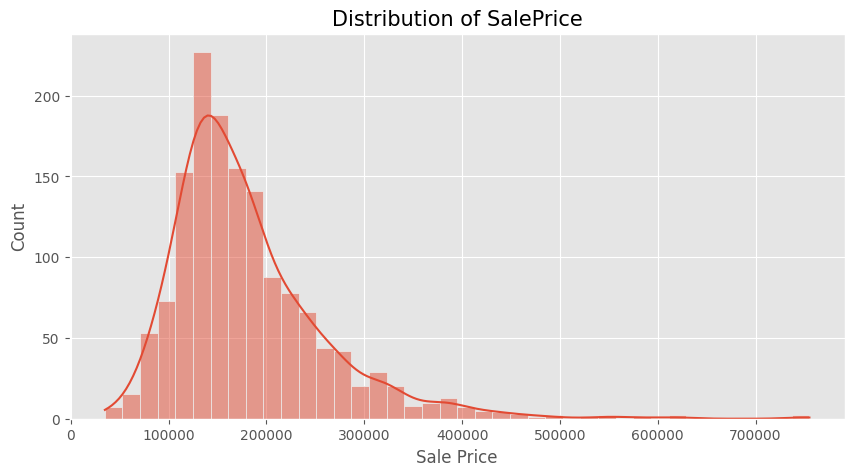

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(train["SalePrice"], bins=40, kde=True)

plt.title("Distribution of SalePrice", fontsize=15)
plt.xlabel("Sale Price")
plt.ylabel("Count")

plt.show()

In [11]:
print(train["SalePrice"].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## Insights from the Target Variable (`SalePrice`)

- The dataset contains **1,460 house sale records** with sale prices ranging from **\$34,900** to **\$755,000**.
- The **average sale price** is **\$180,921**, while the **median sale price** is **\$163,000**. Since the mean is higher than the median, the distribution is **positively (right) skewed**, indicating the presence of high-priced properties.
- The middle 50% of house prices lie between **\$129,975 (25th percentile)** and **\$214,000 (75th percentile)**, suggesting that most homes are sold within this range.
- The histogram confirms that the majority of properties are concentrated between **\$100,000** and **\$200,000**, with the highest density around **\$140,000** – **\$160,000**.
- A small number of luxury homes priced above **\$400,000** create a long right tail, indicating the presence of **high-value outliers**.
- The standard deviation of approximately **\$79,443** reflects considerable variability in house prices across the dataset.
- Since `SalePrice` does **not follow a normal distribution**, applying a **logarithmic transformation** (e.g., `np.log1p(SalePrice)`) is recommended before training regression models. This reduces skewness, minimizes the impact of extreme values, and often improves the performance of linear regression and other predictive models.

#  Numerical Feature Correlation

Correlation helps identify features that have strong relationships with the target variable.

In [12]:
correlation = train.corr(numeric_only=True)

top_corr = correlation["SalePrice"].sort_values(ascending=False)

top_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

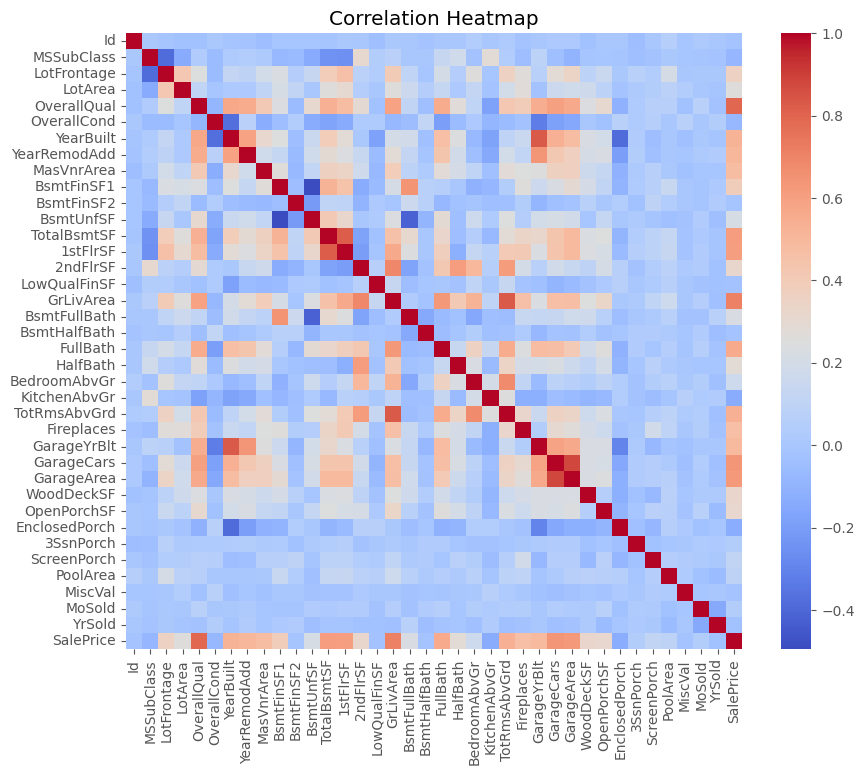

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    square=True,
    cbar=True
)

plt.title("Correlation Heatmap")

plt.show()

#  Top Features Correlated with SalePrice

Let's visualize the features that have the strongest relationship with the target variable.

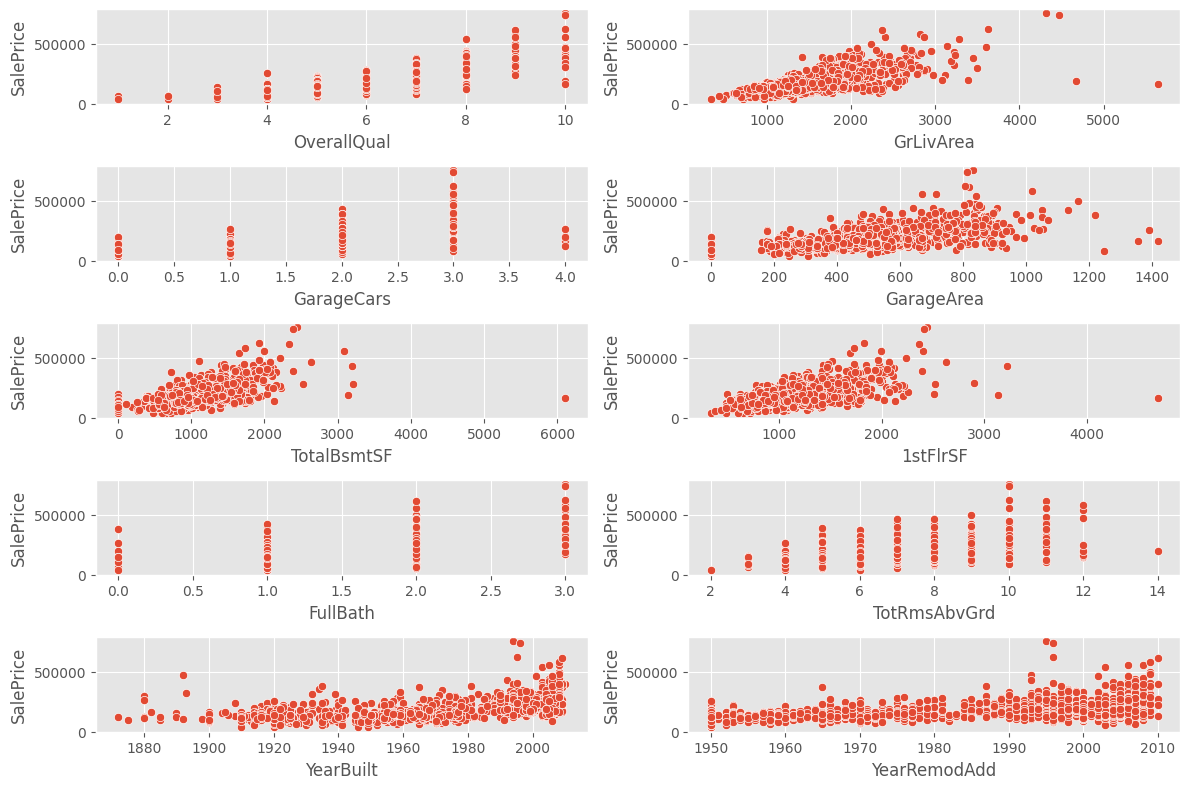

In [14]:
top_features = top_corr.index[1:11]

plt.figure(figsize=(12,8))

for i, feature in enumerate(top_features):

    plt.subplot(5,2,i+1)

    sns.scatterplot(
        x=train[feature],
        y=train["SalePrice"]
    )

    plt.tight_layout()

plt.show()

## Insights from Correlation Analysis with `SalePrice`

- **OverallQual** has the strongest positive correlation with `SalePrice` (**r ≈ 0.79**), indicating that higher construction and material quality significantly increases house prices.
- **GrLivArea** (**r ≈ 0.71**) is the second most influential feature, showing that homes with larger above-ground living areas generally sell for higher prices.
- **GarageCars** and **GarageArea** are strongly correlated with the target, suggesting that properties with larger garages and greater parking capacity are more valuable.
- **TotalBsmtSF** and **1stFlrSF** exhibit strong positive relationships with `SalePrice`, highlighting the importance of usable living space in determining house value.
- **FullBath** and **TotRmsAbvGrd** show moderate positive correlations, indicating that houses with more bathrooms and rooms tend to command higher prices.
- **YearBuilt** and **YearRemodAdd** are positively correlated with `SalePrice`, implying that newer or recently renovated homes generally achieve better market prices.
- Scatter plots confirm these positive relationships, with most key features displaying a clear upward trend, although a few high-priced outliers are present.
- Overall, **quality, living area, garage size, basement area, floor area, and construction year** emerge as the most important numerical predictors of house prices and are likely to contribute significantly to predictive model performance.

# Missing Value Analysis

Real-world datasets often contain missing values.

Before training machine learning models, we need to identify and handle them appropriately.

In this section we will:

- Identify missing values
- Calculate missing percentages
- Visualize missing data
- Remove unnecessary columns
- Fill missing values

In [15]:
missing = train.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [16]:
missing_percent = (missing / len(train)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_df.head(20)

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


#  Missing Value Percentage

Let's visualize which features contain the highest percentage of missing values.

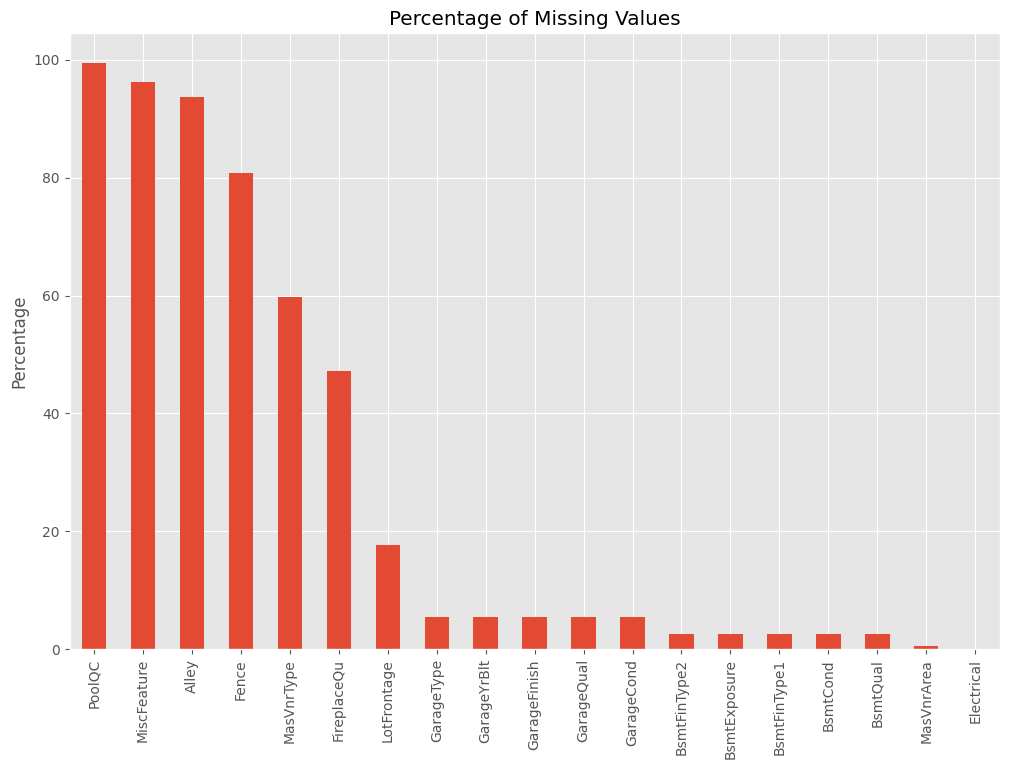

In [17]:
plt.figure(figsize=(12,8))

missing_df["Percentage"].plot(kind="bar")

plt.title("Percentage of Missing Values")

plt.ylabel("Percentage")

plt.show()

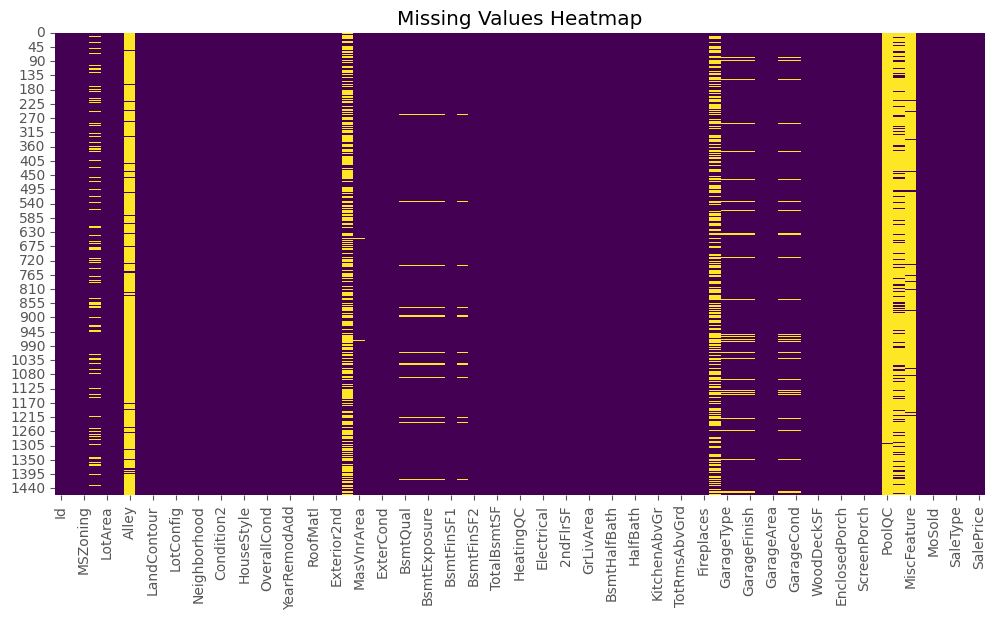

In [18]:
plt.figure(figsize=(12,6))

sns.heatmap(
    train.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

## Insights from Missing Value Analysis

- The dataset contains several features with substantial missing values, but the missingness is concentrated in a relatively small number of columns rather than being spread across the dataset.
- **PoolQC (99.5%)**, **MiscFeature (96.3%)**, **Alley (93.8%)**, and **Fence (80.8%)** have extremely high percentages of missing values, making them strong candidates for removal or special handling during preprocessing.
- **MasVnrType (59.7%)** and **FireplaceQu (47.3%)** also contain significant missing values and require appropriate imputation strategies or domain-specific treatment.
- **LotFrontage (17.7%)** has a moderate proportion of missing values and can be imputed using neighborhood-based statistics (e.g., median frontage within each neighborhood).
- Garage-related features (**GarageType, GarageYrBlt, GarageFinish, GarageQual, GarageCond**) each contain approximately **5.5%** missing values, suggesting that missing entries likely correspond to houses without garages.
- Basement-related features (**BsmtExposure, BsmtFinType1, BsmtFinType2, BsmtQual, BsmtCond**) have only **2–3%** missing values, indicating limited missingness that can be handled through suitable imputation methods.
- The missing values heatmap confirms that missing data is concentrated in specific features rather than randomly distributed across the dataset, highlighting distinct patterns associated with particular house characteristics.
- Overall, the missing value analysis suggests using a combination of **feature removal** for columns with excessive missingness and **targeted imputation** for the remaining features to preserve valuable information while maintaining data quality.

#  Removing Columns with Too Many Missing Values

Features with more than **50% missing values** provide very limited information.

We'll remove them from both the training and testing datasets.

In [19]:
missing_percent = train.isnull().mean()

drop_cols = missing_percent[missing_percent > 0.5].index

print("Columns to Remove:")

print(drop_cols)

Columns to Remove:
Index(['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')


In [20]:
train.drop(columns=drop_cols, inplace=True)

test.drop(columns=drop_cols, inplace=True)

print(train.shape)

print(test.shape)

(1460, 76)
(1459, 75)


In [21]:
print("Remaining Missing Values")

train.isnull().sum().sort_values(ascending=False).head(20)

Remaining Missing Values


FireplaceQu     690
LotFrontage     259
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
BsmtExposure     38
BsmtFinType2     38
BsmtQual         37
BsmtCond         37
BsmtFinType1     37
MasVnrArea        8
Electrical        1
KitchenAbvGr      0
BedroomAbvGr      0
HalfBath          0
FullBath          0
BsmtHalfBath      0
KitchenQual       0
dtype: int64

#  Data Cleaning

Now that we've identified the missing values, let's clean the dataset.

Our strategy:

- Fill numerical missing values with the **median**
- Fill categorical missing values with the **mode**
- Check for duplicate records
- Prepare a clean dataset for feature engineering

# Separate numerical and categorical columns

In [22]:


num_cols = train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = train.select_dtypes(include=["object"]).columns

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 38
Categorical Columns: 38


##  Filling Numerical Missing Values

The **median** is robust to outliers, making it a good choice for numerical features.

In [23]:
for col in num_cols:

    if train[col].isnull().sum() > 0:

        median = train[col].median()

        train[col].fillna(median, inplace=True)

        if col in test.columns:
            test[col].fillna(median, inplace=True)

print("Numerical missing values filled.")

Numerical missing values filled.


##  Filling Categorical Missing Values

For categorical variables, we'll replace missing values using the **most frequent category (mode)**.

In [24]:
for col in cat_cols:

    if train[col].isnull().sum() > 0:

        mode = train[col].mode()[0]

        train[col].fillna(mode, inplace=True)

        if col in test.columns:
            test[col].fillna(mode, inplace=True)

print("Categorical missing values filled.")

Categorical missing values filled.


In [25]:
print("Missing Values in Train Dataset")

int(train.isnull().sum().sum())

Missing Values in Train Dataset


0

## Duplicate Records

Duplicate observations can introduce bias into the model.

Let's check whether the training dataset contains duplicate rows.

In [26]:
duplicates = train.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [27]:
if duplicates > 0:

    train = train.drop_duplicates()

    print("Duplicates Removed!")

else:

    print("No Duplicate Rows Found.")

print("Final Train Shape:", train.shape)
print("Final Test Shape :", test.shape)

No Duplicate Rows Found.
Final Train Shape: (1460, 76)
Final Test Shape : (1459, 75)


#  Feature Engineering

Feature engineering allows us to create more meaningful variables from existing features.

In this section, we'll create:

- Total House Area
- Total Bathrooms
- House Age
- Years Since Remodel
- Total Porch Area
- Total Quality Score

These engineered features often improve model performance significantly.

In [28]:
# Total House Area

train["TotalSF"] = (
    train["TotalBsmtSF"]
    + train["1stFlrSF"]
    + train["2ndFlrSF"]
)

test["TotalSF"] = (
    test["TotalBsmtSF"]
    + test["1stFlrSF"]
    + test["2ndFlrSF"]
)

print("TotalSF feature created.")

TotalSF feature created.


In [29]:
# Total Bathrooms

train["TotalBathrooms"] = (
    train["FullBath"]
    + (0.5 * train["HalfBath"])
    + train["BsmtFullBath"]
    + (0.5 * train["BsmtHalfBath"])
)

test["TotalBathrooms"] = (
    test["FullBath"]
    + (0.5 * test["HalfBath"])
    + test["BsmtFullBath"]
    + (0.5 * test["BsmtHalfBath"])
)

print("TotalBathrooms feature created.")

TotalBathrooms feature created.


##  House Age

Older houses may have different market values than newer ones.

We'll calculate the age of each property based on the construction year.

In [30]:
current_year = 2025

train["HouseAge"] = current_year - train["YearBuilt"]
test["HouseAge"] = current_year - test["YearBuilt"]

print("HouseAge feature created.")

HouseAge feature created.


In [31]:
# Years Since Remodel

train["RemodelAge"] = current_year - train["YearRemodAdd"]
test["RemodelAge"] = current_year - test["YearRemodAdd"]

print("RemodelAge feature created.")

RemodelAge feature created.


In [32]:
# Total Porch Area

train["TotalPorchSF"] = (
    train["OpenPorchSF"]
    + train["EnclosedPorch"]
    + train["3SsnPorch"]
    + train["ScreenPorch"]
)

test["TotalPorchSF"] = (
    test["OpenPorchSF"]
    + test["EnclosedPorch"]
    + test["3SsnPorch"]
    + test["ScreenPorch"]
)

print("TotalPorchSF feature created.")

TotalPorchSF feature created.


In [33]:
# Overall Quality Score

train["QualityScore"] = (
    train["OverallQual"] * train["OverallCond"]
)

test["QualityScore"] = (
    test["OverallQual"] * test["OverallCond"]
)

print("QualityScore feature created.")

QualityScore feature created.


#  Visualizing Engineered Features

Let's examine the distribution of the newly created features.

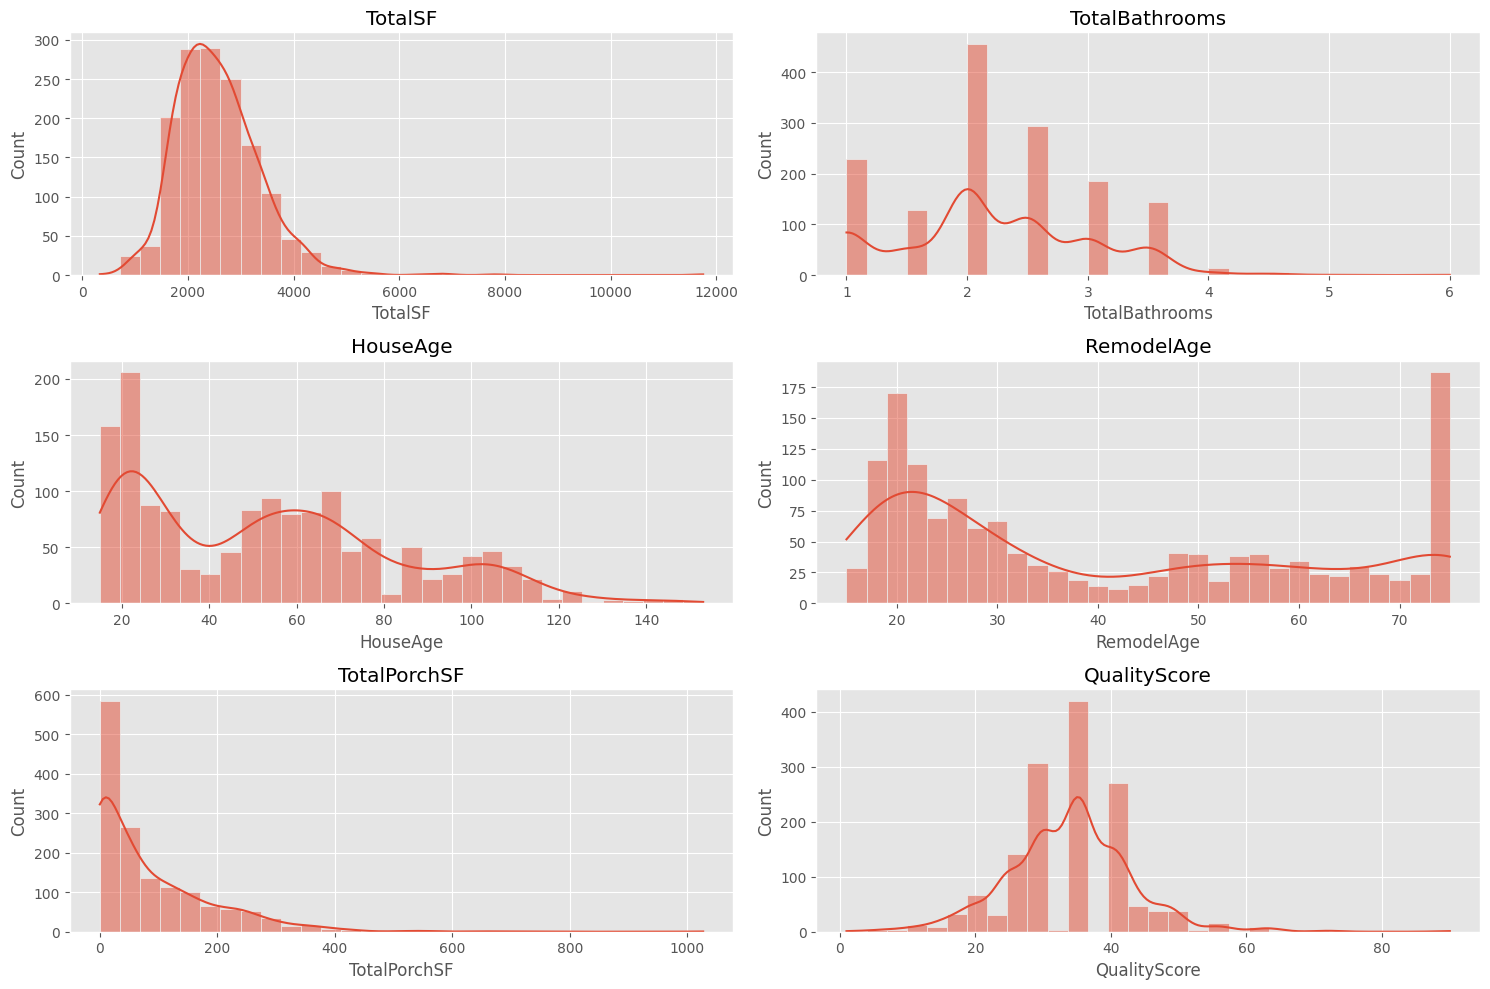

In [34]:
engineered_features = [
    "TotalSF",
    "TotalBathrooms",
    "HouseAge",
    "RemodelAge",
    "TotalPorchSF",
    "QualityScore"
]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(engineered_features):

    plt.subplot(3, 2, i + 1)

    sns.histplot(
        train[feature],
        kde=True,
        bins=30
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

#  Data Preprocessing

Before training machine learning models, we need to preprocess the data.

In this section, we'll:

- Separate features and target
- Apply log transformation to the target
- Encode categorical variables
- Align train and test datasets
- Scale numerical features
- Create training and validation sets

In [35]:
# Separate Features and Target

X = train.drop("SalePrice", axis=1)

y = train["SalePrice"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (1460, 81)
Target Shape : (1460,)


##  Log Transform Target

House prices are usually right-skewed.

Applying a logarithmic transformation often improves model performance.

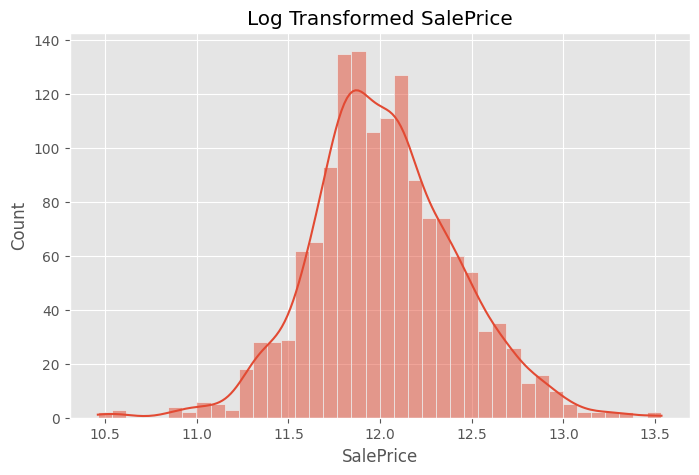

In [36]:
# Log Transformation

y = np.log1p(y)

plt.figure(figsize=(8,5))

sns.histplot(y, bins=40, kde=True)

plt.title("Log Transformed SalePrice")

plt.show()

##  One-Hot Encoding

Machine learning models require numerical inputs.

We'll convert categorical variables into numerical features using One-Hot Encoding.

In [37]:
# Combine train and test for consistent encoding

combined = pd.concat([X, test], axis=0)

combined = pd.get_dummies(
    combined,
    drop_first=True
)

print("Encoded Shape:", combined.shape)

Encoded Shape: (2919, 240)


In [38]:
# Split back into train and test

X = combined.iloc[:len(train), :]

test = combined.iloc[len(train):, :]

print(X.shape)
print(test.shape)

(1460, 240)
(1459, 240)


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

test_scaled = scaler.transform(test)

print("Scaling Completed.")

Scaling Completed.


## Train Validation Split

We'll reserve 20% of the training data for validation.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Validation Shape :", X_valid.shape)

Training Shape : (1168, 240)
Validation Shape : (292, 240)


#  Model Training

Now that our data has been cleaned and preprocessed, we'll train multiple regression models.

Models to compare:

- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost
- CatBoost

We'll evaluate them using:

- RMSE (Root Mean Squared Error)
- R² Score

In [41]:
# Uncomment if needed

# !pip install xgboost
# !pip install catboost

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [42]:
models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )

}

#  Model Evaluation Function

We'll create a reusable function to evaluate each model.

In [43]:
results = []

def evaluate_model(name, model):

    model.fit(X_train, y_train)

    predictions = model.predict(X_valid)

    rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            predictions
        )
    )

    r2 = r2_score(
        y_valid,
        predictions
    )

    results.append([
        name,
        rmse,
        r2
    ])

    print(f"{name} Completed")

In [44]:
for name, model in models.items():

    evaluate_model(name, model)

Linear Regression Completed
Random Forest Completed
Gradient Boosting Completed
XGBoost Completed
CatBoost Completed


In [45]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "RMSE",
        "R2 Score"
    ]

)

results_df = results_df.sort_values(
    by="RMSE"
)

results_df

,Model,RMSE,R2 Score
4,CatBoost,0.133738,0.904154
3,XGBoost,0.135449,0.901686
2,Gradient Boosting,0.137275,0.899017
1,Random Forest,0.147815,0.882915
0,Linear Regression,0.209021,0.765878


#  Model Performance Comparison

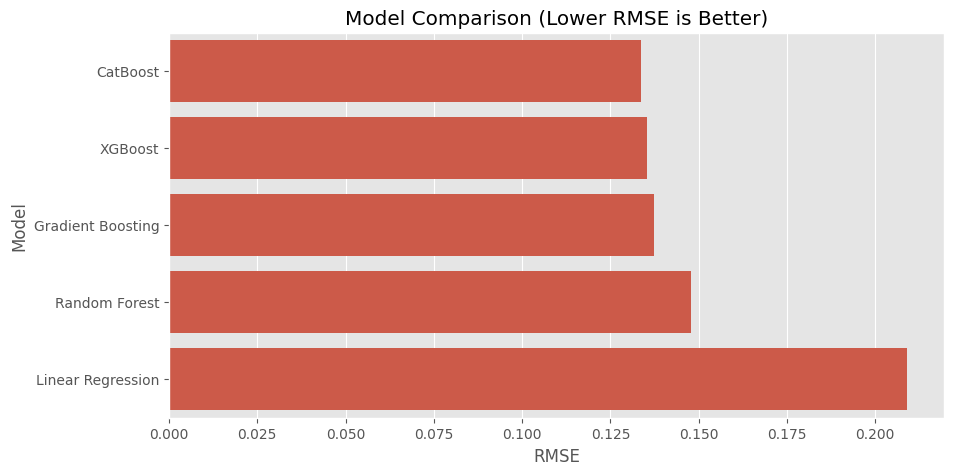

In [46]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)

plt.title("Model Comparison (Lower RMSE is Better)")

plt.show()

In [47]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:")

print(best_model_name)

best_model = models[best_model_name]

Best Model:
CatBoost


#  Final Model Training

Now that we've identified the best-performing model, we'll train it using the entire training dataset.

This allows the model to learn from all available data before making predictions on the test dataset.

In [48]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_scaled,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -cv_scores

print("Cross Validation RMSE")

print(rmse_scores)

print("\nAverage RMSE:", rmse_scores.mean())

Cross Validation RMSE
[0.11193906 0.13358019 0.12561665 0.10769706 0.12860424]

Average RMSE: 0.12148743884093012


In [49]:
best_model.fit(
    X_scaled,
    y
)

print("Model trained on complete dataset.")

Model trained on complete dataset.


#  Predicting House Prices

We'll now generate predictions for the unseen test dataset.

In [50]:
predictions = best_model.predict(test_scaled)

predictions = np.expm1(predictions)

predictions[:10]

array([123295.19946242, 159573.19592463, 185735.46298669, 189152.25100558,
       183271.34279781, 173275.1098795 , 175426.94898577, 167425.22893656,
       187072.38894022, 123217.41698119])

#  Creating Submission File

Kaggle requires two columns:

- Id
- SalePrice

In [51]:
# Recover test IDs
test_ids = test["Id"].copy()

In [52]:
submission = pd.DataFrame({

    "Id": test_ids,

    "SalePrice": predictions

})

submission.head()

,Id,SalePrice
0,1461,123295.199462
1,1462,159573.195925
2,1463,185735.462987
3,1464,189152.251006
4,1465,183271.342798


In [53]:
submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!


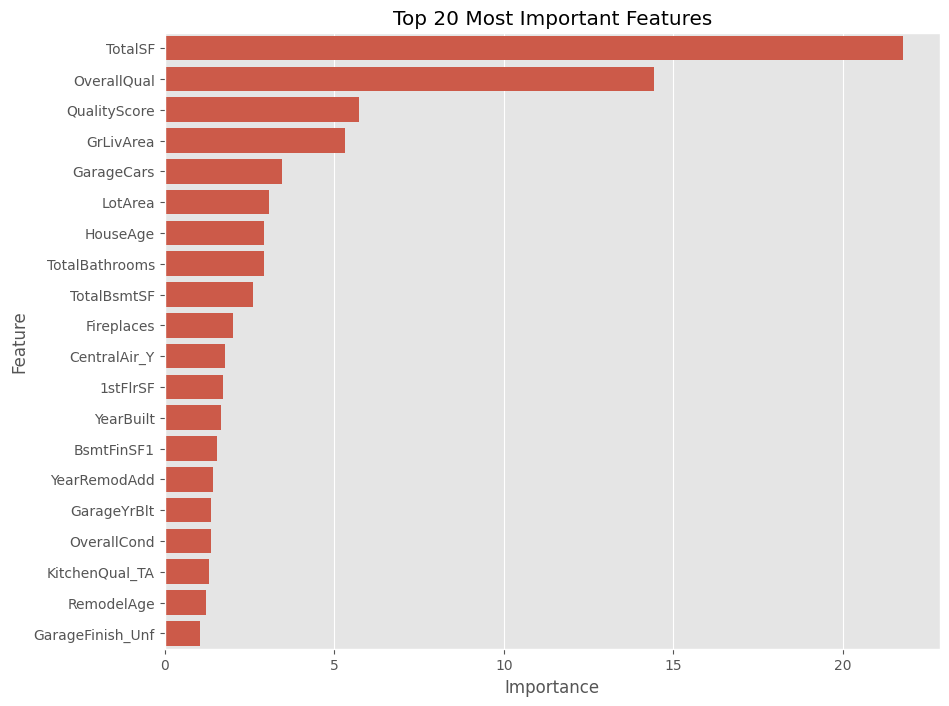

In [54]:
if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,8))

    sns.barplot(
        data=feature_importance.head(20),
        x="Importance",
        y="Feature"
    )

    plt.title("Top 20 Most Important Features")

    plt.show()

else:

    print("Feature importance is not available for this model.")

#  Conclusion

In this notebook, we completed an end-to-end machine learning pipeline for predicting house prices.

## Workflow Summary

✅ Data Loading

✅ Exploratory Data Analysis (EDA)

✅ Missing Value Analysis

✅ Data Cleaning

✅ Feature Engineering

✅ Data Preprocessing

✅ Model Training

✅ Model Comparison

✅ Cross Validation

✅ Final Prediction

✅ Kaggle Submission File

### Future Improvements

- Hyperparameter tuning with Optuna
- LightGBM Regressor
- Advanced feature engineering
- Stacking and blending multiple models
- Ensemble learning for improved leaderboard performance

Thank you for reading this notebook!

If you found it useful, please consider giving it an upvote on Kaggle.